In [74]:
import os
import yaml
import re 

import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as pe
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion

import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [229]:
# filename = '/Users/rishi/Documents/Analysis/palmer/aerie-apps_bin4-9__allsky_1024_i2.5_r0.0_p1.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p5-index2p7-padding1p0-bins_8910_GP.fits'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p0-index2p7-padding1p0-bins_8910_GP.fits'
x = 320
y =  42
# x = 357.3
# y =  42.7
xlength = 20
ylength = 20
coord_sys = 'G' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)

ROI center in Galactic Coordintes = 320, 42
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 320.0 42.0 
CRPIX : 3600.0 3600.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 7200  7200
Fits File loaded
Degrees per pixel: 0.005555555555555556 


288.7983333 10.9455556
No contours to plot
Peak intensity pixel location: (4078, 3566)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (320.25768325, 44.66107342)>
Peak intensity value: 3.776457735336326


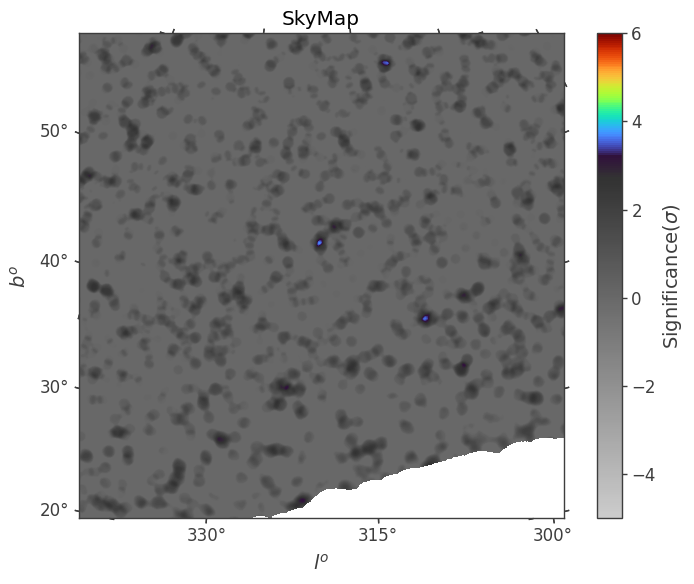

In [230]:
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title='SkyMap', hotspots=seed, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)

In [203]:
# a = [ 'GRS 1915+105']
# b = [288.7983333]
# c = [10.9455556]
# d = [0.1]
# seed = pd.DataFrame({
#     "Name":a, 
#     "ra": b,
#     "dec":  c, 
#     "ext": d,
#     })

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
288.7983333 10.9455556
No contours to plot
Peak intensity pixel location: (903, 1339)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (345.50076021, 12.0111379)>
Peak intensity value: 2.7700289090641004


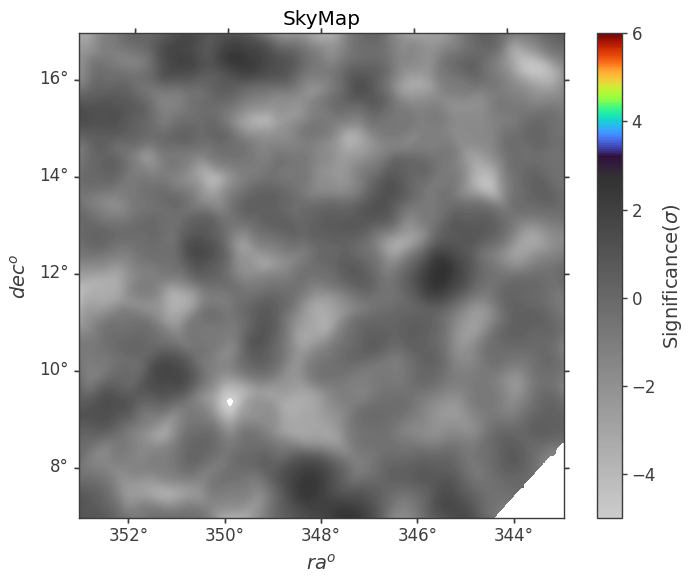

In [204]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
fig=make_plots(array, wcs, pixel_size, coordsys='C', threshold=3, vmin=-5, vmax=6, contour=True, title='SkyMap', hotspots=seed, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)

In [ ]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

In [146]:
# Preprocessing Step: Floor the image for analysis
print(np.min(array))
print(np.max(array))
if np.min(array) < -5:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-5, scale=1.0)

-6.915670943543088
4.2019882471178285
Image softly floored to -5 sigma


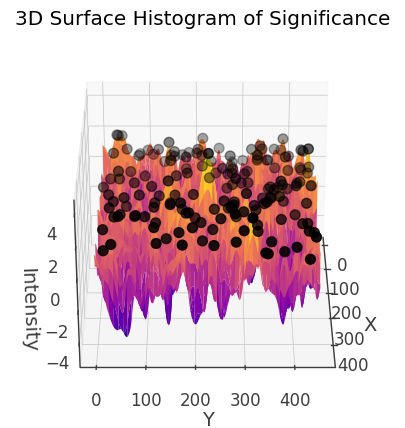

In [147]:
# Make the 3D Intensity Distribution
smoothed = array
smoothed = smoothed[::4, ::4]
x = np.arange(smoothed.shape[1])
y = np.arange(smoothed.shape[0])
X, Y = np.meshgrid(x, y)

coordinates = peak_local_max(smoothed, min_distance=5, threshold_rel=0.1)
peak_x = coordinates[:, 1]
peak_y = coordinates[:, 0]
peak_z = smoothed[peak_y, peak_x]


fig = plt.figure(figsize=(6, 5))#, dpi=80)
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(X, Y, smoothed, cmap='plasma', edgecolor='none')
peaks_plot = ax.scatter(peak_x, peak_y, peak_z, c='black', s=50, label='Peaks')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Intensity')
ax.set_title('3D Surface Histogram of Significance')
def update(frame):
    ax.view_init(elev=30, azim=frame)
    return fig,

ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)
ani.save(f'gaussian_surface_rotation-{1825}.gif', writer='pillow')

Length of bins=3240


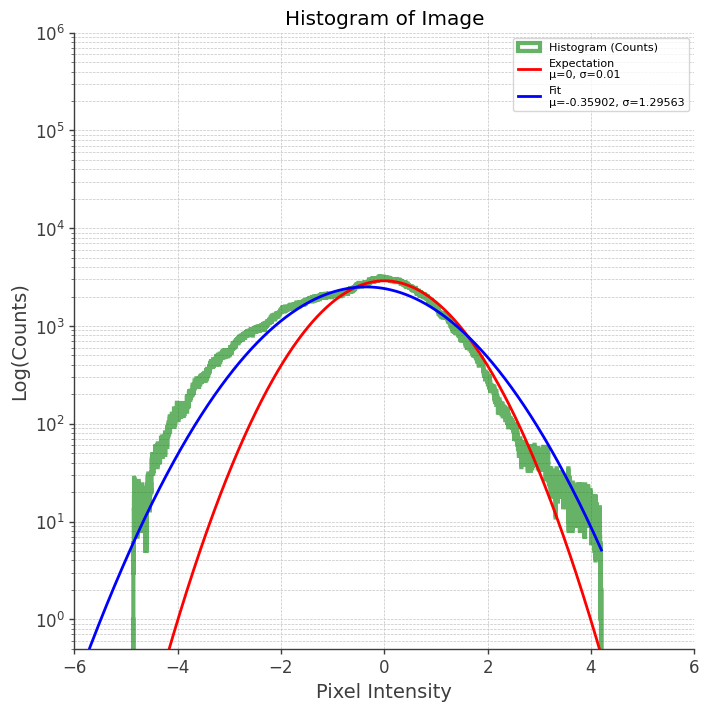

In [148]:
# Calculate the 1D histogram of the image
pixels = array.flatten()
binlen = int(len(pixels)/1000)
print(f"Length of bins={binlen}")
counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(-5, 5, binlen)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
x_fit = np.linspace(-6, np.max(pixels), binlen)
y_fit = gaussian_fit(x_fit, *popt)

plt.figure(figsize=(8, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
plt.yscale('log')
plt.ylim(0.5, 1e6)
plt.xlim(-6, 6)
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>, <WCSAxes: >)

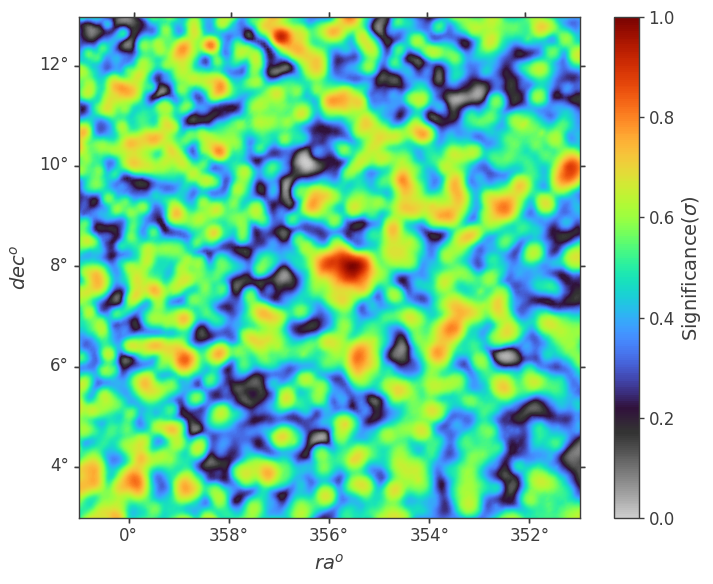

In [149]:
#Normalize the image between 0 and 1 for analysis

image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=0, vmax=1, contour=False, title=None, hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))

0.2729570514893033 0.6360095512729034


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Smeared Image with radius 0.5$^\\degree$'}>)

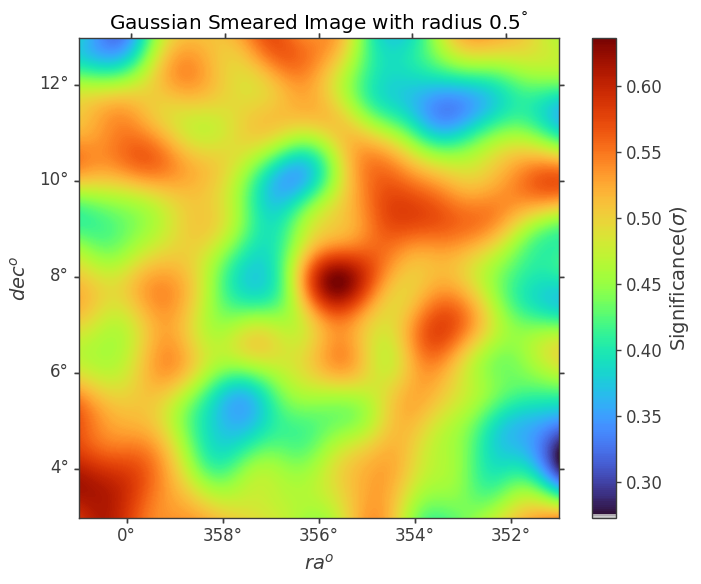

In [150]:
#Smearing Image with a gaussian for visualizing 
image_tmp = norm_image
smear_radius = 0.5
smear_image = gaussian(image_tmp, sigma=smear_radius/pixel_size)
print(np.min(smear_image), np.max(smear_image))
make_plots(smear_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=np.min(smear_image), vmax=np.max(smear_image), title=f"Gaussian Smeared Image with radius {smear_radius}$^\degree$", cmap='ult')

36.0
288.7983333 10.9455556


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

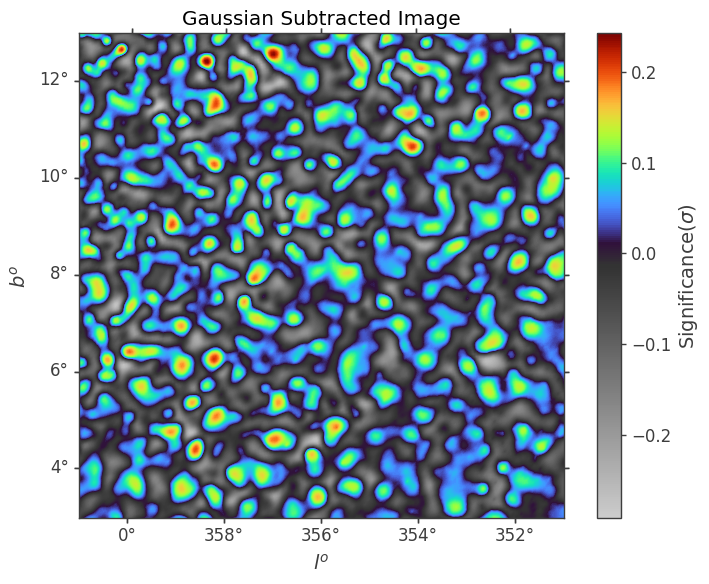

In [151]:
# Find the Difference of Gaussian (DoG) Image
psf=0.2                  #PSF of the dec band
print(psf/pixel_size)
dog_image = difference_of_gaussians(norm_image, 1, psf/pixel_size)
# dog_image = gaussian(dog_image)
make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.000005, hotspots=seed,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image', cmap='ult')#, labels=['4hawc'])

Significant deviation from Gaussian on positive side at:93,  -0.04196


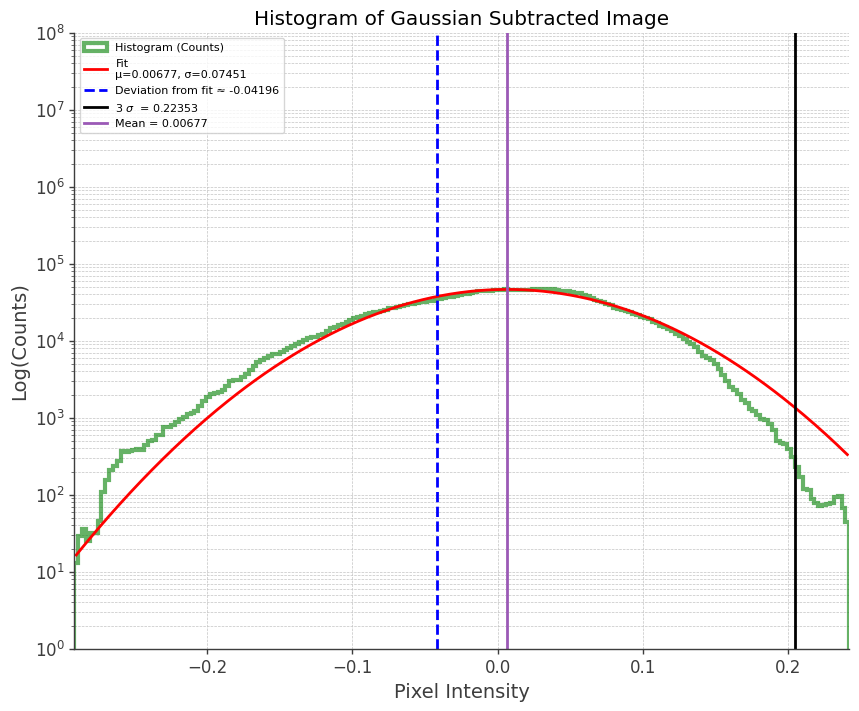

In [152]:
# Calculate the 1D histogram of the DoG Image
from scipy.interpolate import interp1d
pixels = dog_image.flatten()
sigma_resid2 = np.std(dog_image)


counts, bin_edges = np.histogram(pixels, bins=200, range=(np.min(pixels), np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(np.min(bin_edges), np.max(bin_edges), 200)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 0.01)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
x_fit = np.linspace(bin_centers[0], bin_centers[-1], 500)
y_fit = gaussian_fit(x_fit, *popt)


fit_interp = interp1d(x_fit, y_fit, bounds_error=False, fill_value=0)
gaussian_at_bins = fit_interp(bin_centers)

# Compute deviation mask: where histogram exceeds Gaussian expectation significantly
deviation_mask = (bin_centers > popt[1]) & (counts > 1.1 * gaussian_at_bins)

for i in range(len(deviation_mask)):
    if np.all(deviation_mask[i:]):
        j = i
        break
deviation_location = bin_centers[j]
print(f"Significant deviation from Gaussian on positive side at:{j},  {deviation_location:.5f}")
# if np.any(deviation_mask):
#     dev_idx = np.argmax(deviation_mask)
#     # print(dev_idx)
#     # for i in range(dev_idx, len(deviation_mask)):
#         # if deviation_mask[i]:
#             # print(i)
#     deviation_index = np.argmax(deviation_mask)
#     deviation_location = bin_centers[deviation_index]
#     print(f"First significant deviation from Gaussian on positive side at: {deviation_location:.5f}")
# else:
#     print("No significant deviation found on the positive side.")
sigma_resid = popt[2]
deviation = 2.75*sigma_resid
plt.figure(figsize=(10, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=200, range=(np.min(pixels), np.max(pixels)),  color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)',histtype='step', linewidth=3)
# plt.plot(x_exp, y_exp, 'cyan', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
if np.any(deviation_mask):
    plt.axvline(deviation_location, color='blue', linestyle='--', linewidth=2, 
                label=f'Deviation from fit ≈ {deviation_location:.5f}')
plt.axvline(deviation, label=f'3 $\sigma$  = {3*popt[2]:.5f}', color='black')
plt.axvline(popt[1], label=f'Mean = {popt[1]:.5f}')
plt.yscale('log')
plt.ylim(1, 1e8)
plt.xlim(np.min(bin_edges), np.max(bin_edges))
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Gaussian Subtracted Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

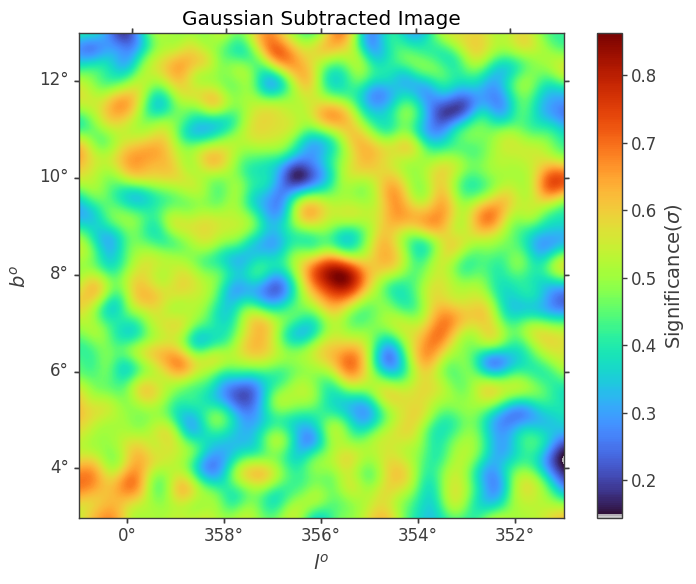

In [153]:
lowfreq_image=norm_image-dog_image
lowfreq_image = gaussian(lowfreq_image, sigma=3)
make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])#, figsize=(20, 10))

In [154]:
# Find the blobs from the DoG image
ps_blobs = blob_dog(norm_image, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=0.01, exclude_border=20, overlap=0.5)
print("Number of point source blobs=",len(ps_blobs))
ext_blobs = blob_dog(norm_image,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=0.01, exclude_border=20, overlap=0.5)
print("Number of ext source blobs=",len(ext_blobs))

ps_blobs = ps_blobs[ps_blobs[:, 2] < psf/pixel_size]
ext_blobs = ext_blobs[ext_blobs[:, 2] > psf/pixel_size]
print("Number of point source blobs=",len(ps_blobs))
print("Number of ext source blobs=",len(ext_blobs))

Number of point source blobs= 220
Number of ext source blobs= 91
Number of point source blobs= 220
Number of ext source blobs= 11


In [155]:
meowge = dog_image

gradx, grady =  np.gradient(meowge)
div = gradx + grady

div_norm = (div - np.min(div)) / np.max(div - np.min(div))
meowge = div_norm * meowge
clahe = exposure.equalize_adapthist(meowge)
mu1 = np.mean(meowge)
std1 = np.std(meowge)
threshold1 = 0.01 * (mu1 + 3 * std1)
print("Finding point source blobs")
ps_blobs = blob_dog(meowge, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=threshold1, exclude_border=20)#, overlap=0.9)
print("Number of point source blobs=",len(ps_blobs))
print("Finding extended source blobs")
ext_blobs = blob_dog(meowge,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=threshold1, exclude_border=20)#, overlap=0.9)
print("Number of ext source blobs=",len(ext_blobs))

Finding point source blobs
Number of point source blobs= 291
Finding extended source blobs
Number of ext source blobs= 124


In [156]:
# DoG Image Intensity Filtering
deviation=deviation_location
intensity_min = deviation
intensity_min2 = deviation

# %load_ext autoreload
# %autoreload 2
# %reload_ext autoreload

print(intensity_min2)
ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs))
ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min2, wcs, pixel_size)
print("No of ext = ", len(ext_filtered_blobs))

-0.041959078999957225
Blob Intensity 0.21170429427945134, Coords (254.02317640396882 deg, -23.23622248054865 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 0.20854898113424175, Coords (252.99081197545135 deg, -24.224683152077876 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 0.17785852648610986, Coords (257.4521896654445 deg, -24.67605772107798 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 0.1835790340326778, Coords (261.36715169182366 deg, -27.73774778713388 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 0.19277497053246856, Coords (259.38760133509487 deg, -26.978053398712866 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 0.17253812251396136, Coords (260.33703394648813 deg, -25.485997997635426 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 0.14969326045150985, Coords (260.5063559523249 deg, -27.122354787225586 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 0.17247751859131916, Coords (254.65890425956343 deg, -23.884040745071616 deg), Radius 28.8, Pixel Rad

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

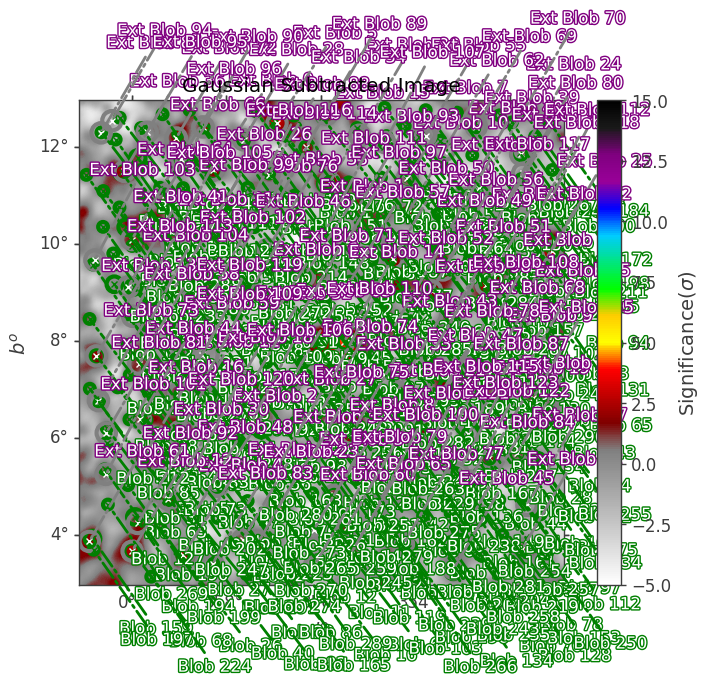

In [157]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
blobs_dict = {
    'psblobs': ps_filtered_blobs,
    'extblobs': ext_filtered_blobs,
}
make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap=milagro)#, labels=['4hawc'])
# make_logplots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap=milagro)#, labels=['4hawc'])

In [158]:
# Input Significance Image Intensity Filtering
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))

No of ps =  0
No of ext =  0


(<Figure size 2000x1000 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

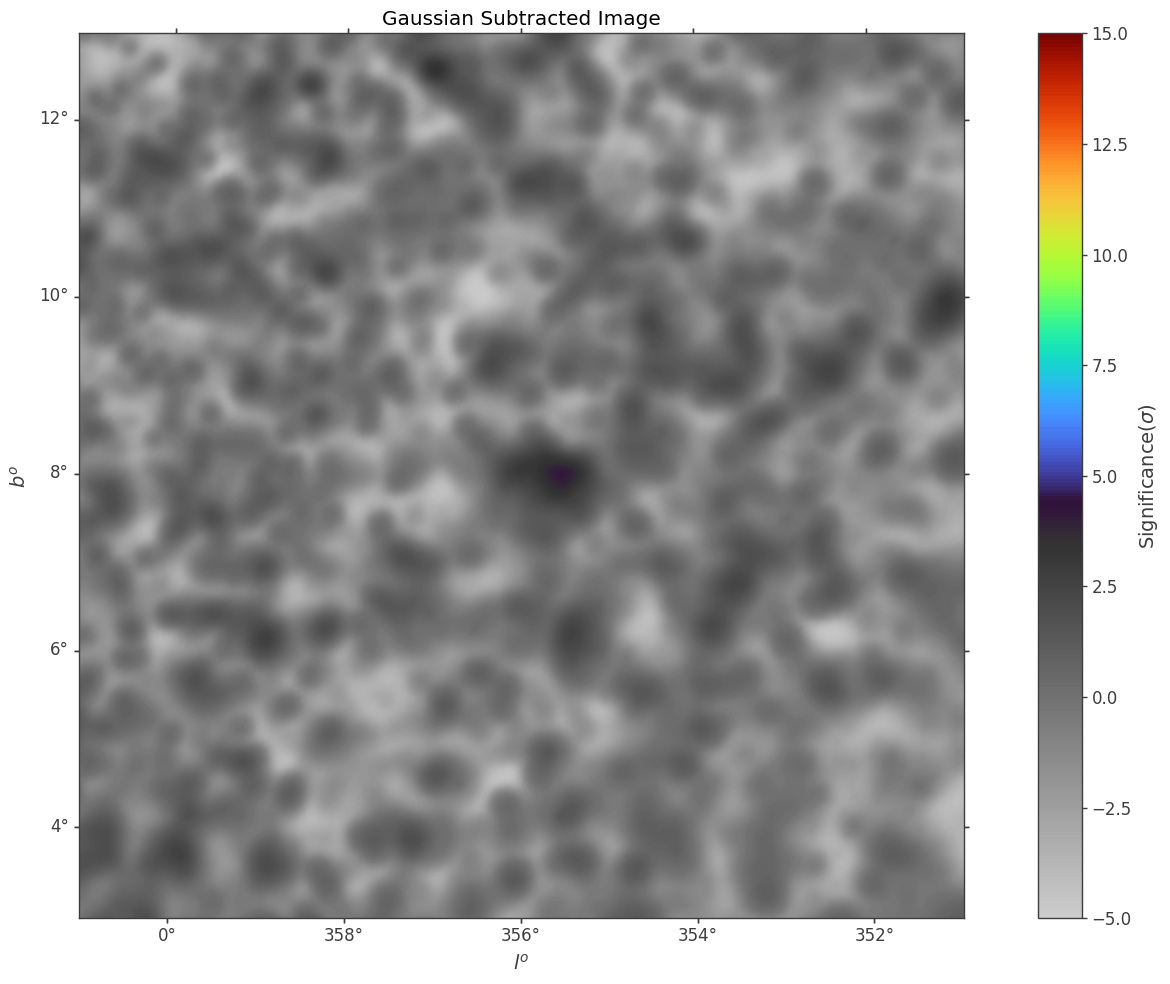

In [159]:
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs3,
}

# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])
make_plots(array, wcs, pixel_size,coordsys='G', blobs=blobs_dict,title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'], figsize=(20, 10))

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

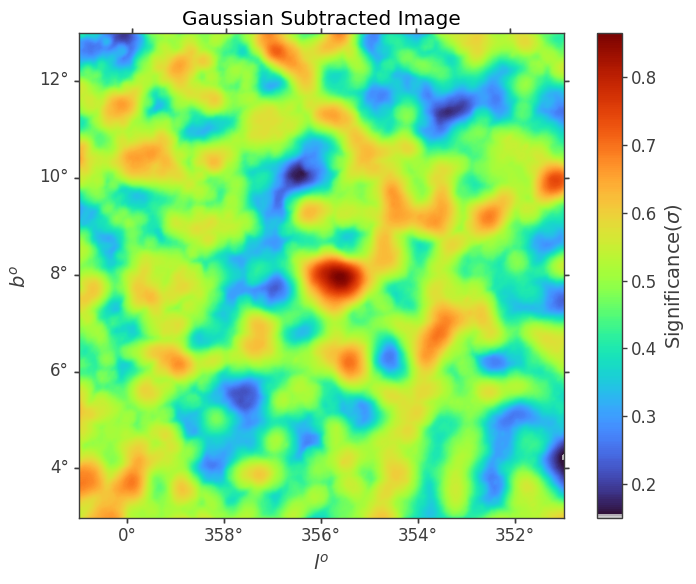

In [160]:
lowfreq_image=norm_image-gaussian(dog_image, sigma=8)
lowfreq_image = gaussian(lowfreq_image, sigma=3)

make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#,

In [161]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs4 = blob_dog(lowfreq_image,min_sigma=0.4/pixel_size, max_sigma=0.8/pixel_size, threshold=0.001, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs4))

Number of ext source blobs= 23


Blob Intensity 3.036583353739356, Coords (256.23210265711447 deg, -28.056335457349267 deg), Radius 72.0, Pixel Radius 0.4


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

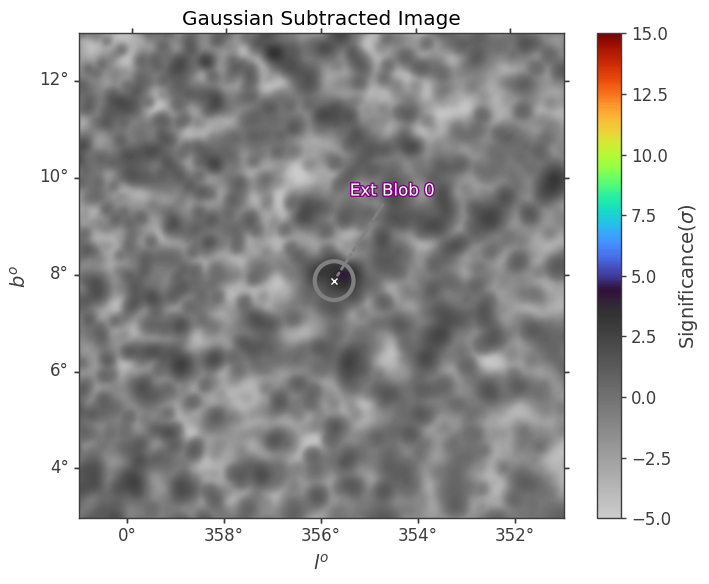

In [162]:
# Filter the Gaussian Blobs from above
ext_filtered_blobs4, ext_filtered_coords4, ext_filtered_radius4 = blob_filter_intensity(ext_blobs4, array, 3, wcs, pixel_size)

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs4,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['mp'])

In [163]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs2 = blob_dog(lowfreq_image,min_sigma=0.8/pixel_size, max_sigma=1.5/pixel_size, threshold=0.005, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs2))

Number of ext source blobs= 4


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

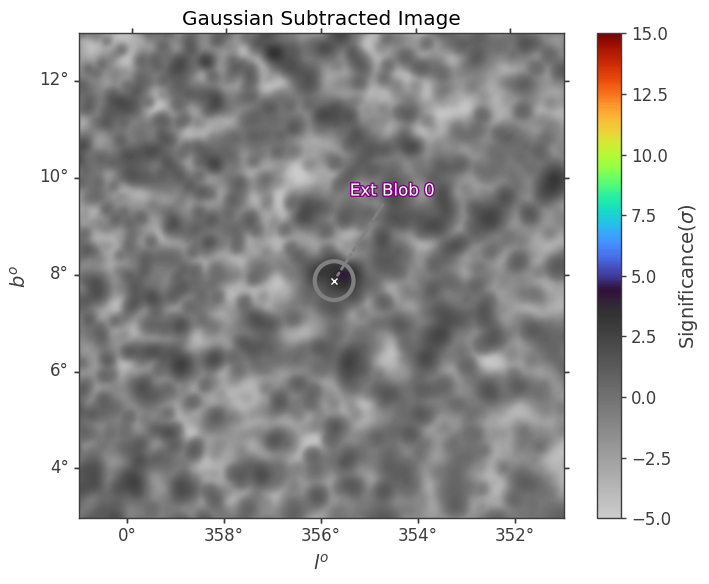

In [164]:
# Filter the Gaussian Blobs from above
ext_filtered_blobs2, ext_filtered_coords2, ext_filtered_radius2 = blob_filter_intensity(ext_blobs2, array, 4.5, wcs, pixel_size)
temp_ext = ext_filtered_blobs4+ext_filtered_blobs2
blobs_dict = {
    # 'psblobs': ps_filtered_blobs2,
    # 'extblobs': ext_filtered_blobs2,
    'extblobs': temp_ext,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult')#, labels=['4hawc'])

In [165]:
from astropy.coordinates import SkyCoord
import astropy.units as u

def remove_overlapping_ext_sources(primary_coords, candidate_coords, threshold_deg=0.3):

    primary = SkyCoord([c.ra.deg for c in primary_coords] * u.deg,
                       [c.dec.deg for c in primary_coords] * u.deg)
    filtered_candidates = []

    for cand in candidate_coords:
        sep = cand.separation(primary)
        if np.all(sep.deg >= threshold_deg):
            filtered_candidates.append(cand)

    return filtered_candidates


def filter_overlapping_sources(coords, radii, radius_to_sigma, name_prefix="Drip", max_distance_deg=0.5):

    df = pd.DataFrame({
        'Names': [f'{name_prefix}{i}' for i in range(len(coords))],
        'ra': [c.ra.deg for c in coords],
        'dec': [c.dec.deg for c in coords],
        'Circle Radius': radii,
    })
    df['Sigma Radius'] = [radius_to_sigma(r) for r in radii]

    keep = np.ones(len(df), dtype=bool)
    skycoords = SkyCoord(ra=df['ra'].values * u.deg, dec=df['dec'].values * u.deg)

    for i in range(len(df)):
        if not keep[i]:
            continue
        sep = skycoords[i].separation(skycoords[i+1:]).deg
        for j_offset, dist in enumerate(sep):
            j = i + 1 + j_offset
            if not keep[j]:
                continue
            if dist < max_distance_deg:
                r1 = df.loc[i, 'Sigma Radius']
                r2 = df.loc[j, 'Sigma Radius']
                if r1 > 0.1 and r2 <= 0.1:
                    keep[j] = False
                elif r2 > 0.1 and r1 <= 0.1:
                    keep[i] = False
                else:
                    keep[j if r1 < r2 else i] = False

    return df[keep].reset_index(drop=True)
def remove_overlapping_ext_sources_with_indices(primary_coords, candidate_coords, threshold_deg=1):
    primary = SkyCoord([c.ra.deg for c in primary_coords] * u.deg,
                       [c.dec.deg for c in primary_coords] * u.deg)

    keep_indices = []
    for idx, cand in enumerate(candidate_coords):
        sep = cand.separation(primary)
        if np.all(sep.deg >= threshold_deg):
            keep_indices.append(idx)
    return keep_indices

from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

def remove_ext_sources_with_radius_overlap(t_coords, t_radii, candidate_coords, candidate_radii):
    """
    Removes candidate sources that overlap with any t_coord based on combined radius.

    Parameters:
    ----------
    t_coords : list of SkyCoord
        Existing sources (points or extended).
    t_radii : list of float
        Angular radii (in degrees) for t_coords.
    candidate_coords : list of SkyCoord
        Candidate extended sources to filter.
    candidate_radii : list of float
        Radii for candidate_coords (degrees).

    Returns:
    -------
    keep_indices : list of int
        Indices of candidate_coords that do NOT overlap with any t_coords.
    """
    assert len(candidate_coords) == len(candidate_radii)
    assert len(t_coords) == len(t_radii)

    t_sky = SkyCoord(ra=[c.ra.deg for c in t_coords] * u.deg,
                     dec=[c.dec.deg for c in t_coords] * u.deg)

    keep_indices = []
    for idx, (cand, r_cand) in enumerate(zip(candidate_coords, candidate_radii)):
        sep = cand.separation(t_sky).deg
        combined_radius = r_cand + np.array(t_radii)
        overlaps = sep <= combined_radius
        if not np.any(overlaps):
            keep_indices.append(idx)

    return keep_indices




In [166]:

# # Define primary group t = ps + ext group 2
# t_coords = ps_filtered_coords2 + ext_filtered_coords2

# valid_idx = remove_overlapping_ext_sources_with_indices(t_coords, ext_filtered_coords4)

# # Filter all lists
# ext_filtered_coords4 = [ext_filtered_coords4[i] for i in valid_idx]
# ext_filtered_radius4 = [ext_filtered_radius4[i] for i in valid_idx]
# ext_filtered_blobs4 = [ext_filtered_blobs4[i] for i in valid_idx]

all_coords = ps_filtered_coords2 + ext_filtered_coords2 + ext_filtered_coords3 + ext_filtered_coords4
all_radii = ps_filtered_radius2 + ext_filtered_radius2 + ext_filtered_radius3 + ext_filtered_radius4

filtered_df = filter_overlapping_sources(all_coords, all_radii, radius_to_sigma)

In [167]:
t_coords = ps_filtered_coords2 + ext_filtered_coords2
t_radii = ps_filtered_radius2 + ext_filtered_radius2

# Filter ext group 4
valid_idx = remove_ext_sources_with_radius_overlap(
    t_coords, t_radii,
    ext_filtered_coords4, ext_filtered_radius4
)

# Apply filtering
ext_filtered_coords4 = [ext_filtered_coords4[i] for i in valid_idx]
ext_filtered_radius4 = [ext_filtered_radius4[i] for i in valid_idx]
ext_filtered_blobs4  = [ext_filtered_blobs4[i]  for i in valid_idx]

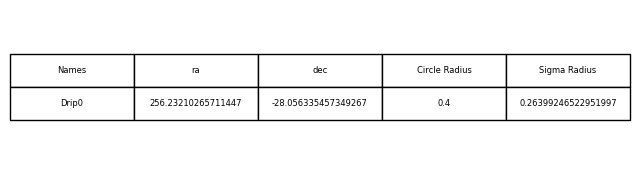

In [168]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

In [2]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs2,
}
# make_plots(array, wcs, pixel_size, coordsys='G', hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc', '4fgl', 'hgps', 'psr', 'snr'], figsize=(20, 10))
# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['N'], figsize=(20, 10))
make_plots(array, wcs, pixel_size,threshold=4, coordsys='G',hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'], figsize=(16, 8))

NameError: name 'pd' is not defined

256.23210265711447 -28.056335457349267


(<Figure size 1600x800 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

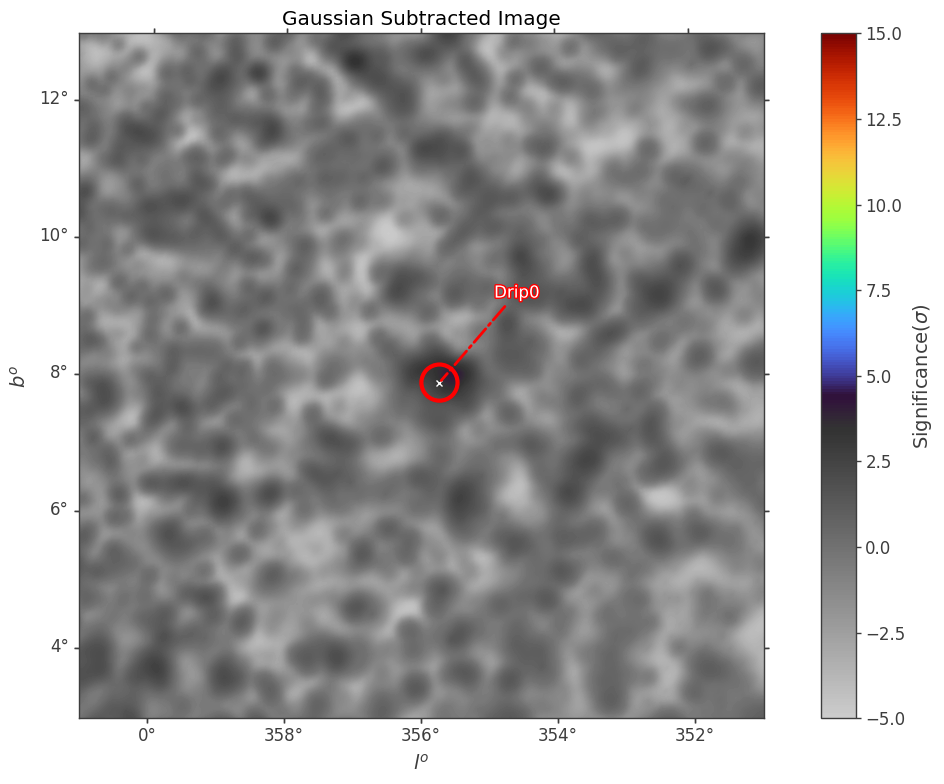

In [170]:
# Plot the Final Seeds
# %load_ext autoreload
# %autoreload 2
# %reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs2,
}
# make_plots(array, wcs, pixel_size, coordsys='G', hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc', '4fgl', 'hgps', 'psr', 'snr'], figsize=(20, 10))
make_plots(array, wcs, pixel_size, coordsys='G', blobs=None, hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc', '4fagl'], figsize=(16, 8),)
# make_logplots(array, wcs, pixel_size,threshold=4, vmin=-4, vmax=15, coordsys='G',hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'], figsize=(16, 8))

288.7983333 10.9455556


(<Figure size 1600x800 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

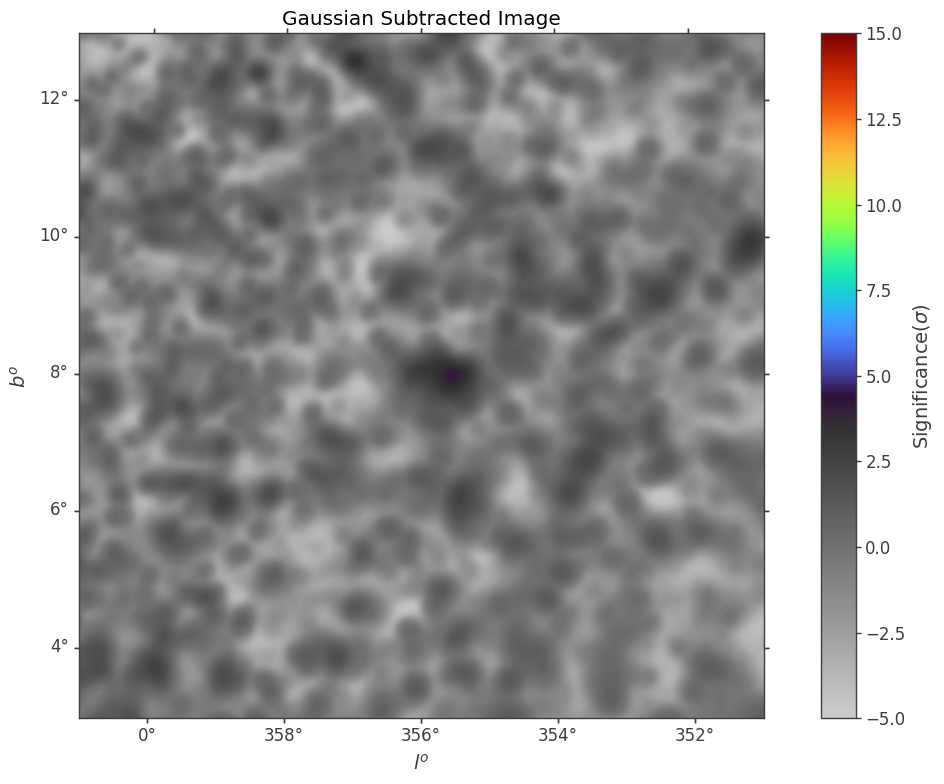

In [171]:
make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, hotspots=seed, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc', '4fagl'], figsize=(16, 8),)

In [172]:

meowge = lowfreq_image

gradx, grady =  np.gradient(meowge)
div = gradx + grady

div_norm = (div - np.min(div)) / np.max(div - np.min(div))
meowge = div_norm * meowge

clahe = exposure.equalize_adapthist(meowge)
mu1 = np.mean(meowge)
std1 = np.std(meowge)
threshold1 = 0.01 * (mu1 + 3 * std1)

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

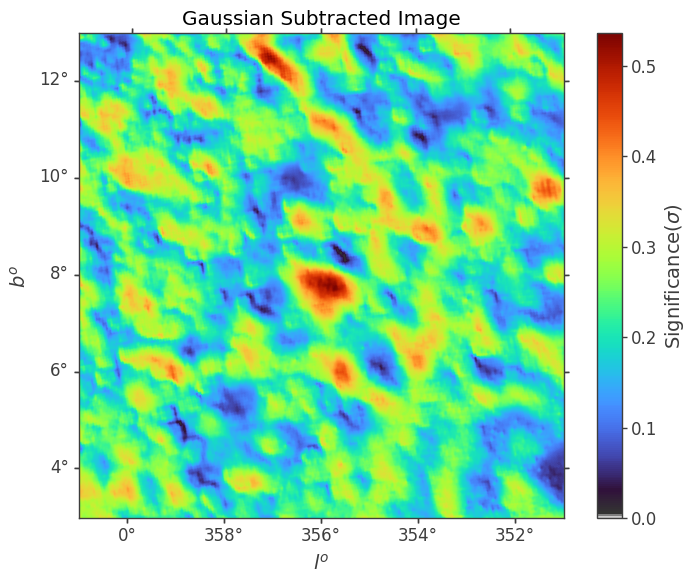

In [173]:
make_plots(meowge, wcs, pixel_size, vmin=np.min(meowge), vmax=np.max(meowge), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#,

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

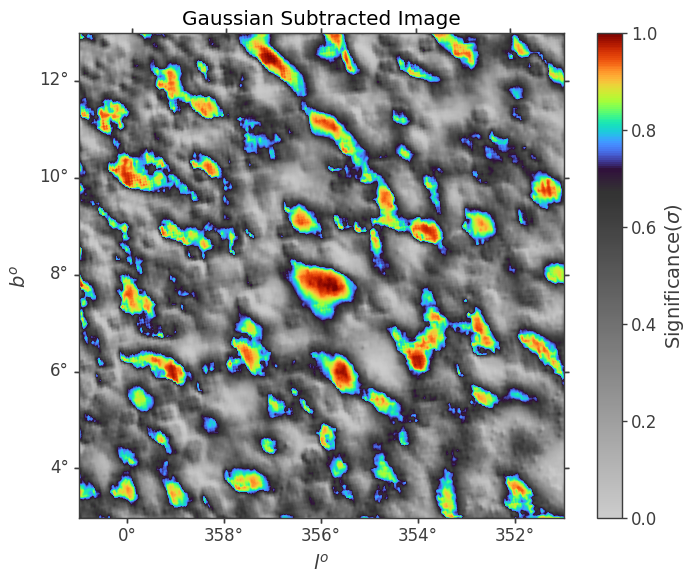

In [174]:
make_plots(clahe, wcs, pixel_size, vmin=np.min(clahe), vmax=np.max(clahe), threshold=0.7,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#,